In [146]:
import os
import warnings

import agama
import astropy
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.interpolate import griddata, interp1d
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.stats import binned_statistic_2d, gaussian_kde
from sklearn.svm import SVC


In [147]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

snap = 600

In [148]:
public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

In [149]:
in_situ_msk = True  # True for include in_situ
ex_situ_msk = False  # True for include ex_situ

In [150]:
it_dict = {}
for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    amsk = src_dat["grpid"][()] == 0

    if (in_situ_msk) & (not ex_situ_msk):
        msk = amsk
    elif (not in_situ_msk) & (ex_situ_msk):
        msk = ~amsk
    else:
        msk = np.ones(len(amsk), dtype=bool)

    m_tfo = 10 ** src_dat["logm_tfor"][msk]
    m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][msk])

    m_tz0_log = src_dat["logm_tz0"][msk]
    m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

    tfor = src_dat["tfor"][msk]
    tdis = src_dat["tdis"][msk]

    age = time - tfor
    age_p = np.array([x - y if x != -1 else time - y for x, y in zip(tdis, tfor)])

    t_tz0 = src_dat["torb_600"][msk]
    s_tz0 = np.array(src_dat["s_flag"][msk], dtype=bool)

    ml = m_tfo_ev - m_tz0
    ml_rate = (m_tfo_ev - m_tz0) / age_p

    it_dict[it_id] = {}
    it_dict[it_id]["m_tfo"] = m_tfo
    it_dict[it_id]["m_tfo_ev"] = m_tfo_ev
    it_dict[it_id]["m_tz0"] = m_tz0
    it_dict[it_id]["tfor"] = tfor
    it_dict[it_id]["tdis"] = tdis
    it_dict[it_id]["age"] = age
    it_dict[it_id]["age_p"] = age_p
    it_dict[it_id]["t_tz0"] = t_tz0
    it_dict[it_id]["s_tz0"] = s_tz0
    it_dict[it_id]["ml"] = ml
    it_dict[it_id]["ml_rate"] = ml_rate

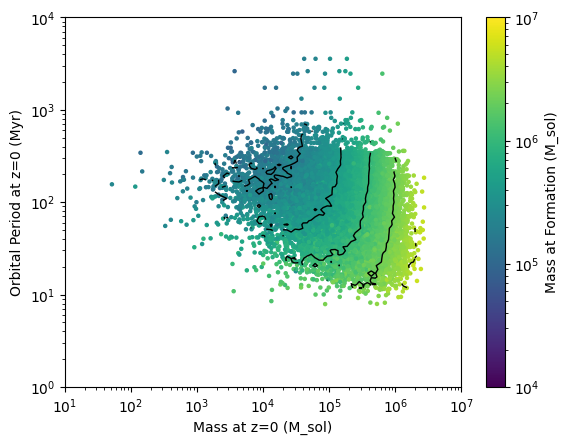

In [151]:
x = np.array([])
y = np.array([])
c = np.array([])

for it_id in it_dict.keys():
    msk_i = it_dict[it_id]["s_tz0"]

    x_i = it_dict[it_id]["m_tz0"][msk_i]
    y_i = it_dict[it_id]["t_tz0"][msk_i]
    c_i = it_dict[it_id]["m_tfo"][msk_i]

    x = np.concatenate((x, x_i))
    y = np.concatenate((y, y_i))
    c = np.concatenate((c, c_i))

plt.scatter(x, y, c=c, norm=LogNorm(vmin=10**4, vmax=10**7), s=5)
plt.colorbar(label="Mass at Formation (M_sol)")

plt.xlabel("Mass at z=0 (M_sol)")
plt.ylabel("Orbital Period at z=0 (Myr)")

plt.xscale("log")
plt.yscale("log")

plt.xlim(10**1, 10**7)
plt.ylim(10**0, 10**4)

# ---- compute contours ----

# Work in log space
logx = np.log10(x)
logy = np.log10(y)

xbins = np.linspace(1, 7, 100)  # log10(1e1) to log10(1e7)
ybins = np.linspace(0, 4, 100)  # log10(1e0) to log10(1e4)

# Median mass per bin
stat, xedges, yedges, _ = binned_statistic_2d(logx, logy, c, statistic="median", bins=[xbins, ybins])

# Bin centers
xc = 0.5 * (xedges[1:] + xedges[:-1])
yc = 0.5 * (yedges[1:] + yedges[:-1])

Xc, Yc = np.meshgrid(xc, yc, indexing="ij")

# Convert back to linear for plotting
plt.contour(10**Xc, 10**Yc, stat, levels=np.logspace(4, 7, 10), colors="black", linewidths=1)

<a list of 6 text.Text objects>

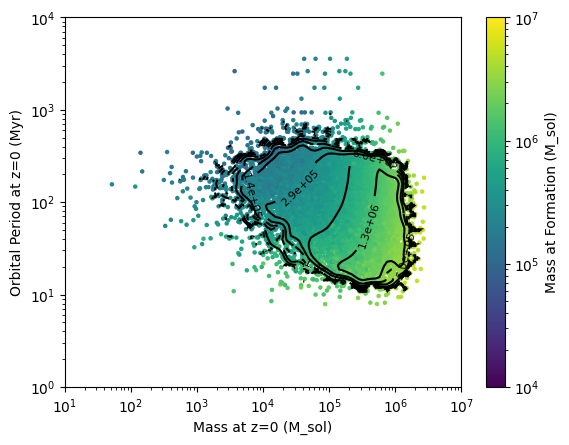

In [152]:
# ---- Scatter ----
plt.scatter(x, y, c=c, norm=LogNorm(vmin=1e4, vmax=1e7), s=5)

plt.colorbar(label="Mass at Formation (M_sol)")

plt.xlabel("Mass at z=0 (M_sol)")
plt.ylabel("Orbital Period at z=0 (Myr)")

plt.xscale("log")
plt.yscale("log")

plt.xlim(1e1, 1e7)
plt.ylim(1e0, 1e4)

# ---- Contours ----

logx = np.log10(x)
logy = np.log10(y)

xbins = np.linspace(1, 7, 100)
ybins = np.linspace(0, 4, 100)

stat, xedges, yedges, _ = binned_statistic_2d(logx, logy, c, statistic="median", bins=[xbins, ybins])

# Mask NaNs before smoothing
stat = np.ma.masked_invalid(stat)

# Smooth (tune sigma if needed)
stat_smooth = gaussian_filter(stat.filled(np.nan), sigma=1.5)

stat_log = np.log10(stat)
stat_log = np.ma.masked_invalid(stat_log)

stat_smooth = gaussian_filter(stat_log.filled(0), sigma=1.5)
stat_smooth[stat_log.mask] = np.nan

levels = np.linspace(np.nanmin(stat_smooth), np.nanmax(stat_smooth), 20)

cs = plt.contour(10**Xc, 10**Yc, 10**stat_smooth, levels=10**levels, colors="black", linewidths=1.5)

plt.clabel(cs, inline=True, fontsize=8, fmt="%.1e")


<a list of 6 text.Text objects>

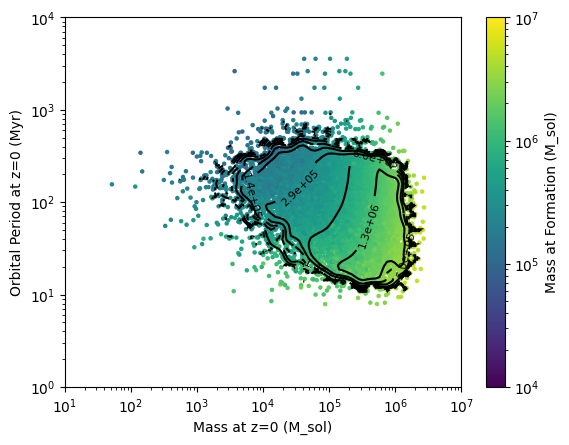

In [153]:
# ---- Scatter ----
plt.scatter(x, y, c=c, norm=LogNorm(vmin=1e4, vmax=1e7), s=5)

plt.colorbar(label="Mass at Formation (M_sol)")

plt.xlabel("Mass at z=0 (M_sol)")
plt.ylabel("Orbital Period at z=0 (Myr)")

plt.xscale("log")
plt.yscale("log")

plt.xlim(1e1, 1e7)
plt.ylim(1e0, 1e4)

# ---- Contours ----

logx = np.log10(x)
logy = np.log10(y)
logc = np.log10(c)

xbins = np.linspace(1, 7, 100)
ybins = np.linspace(0, 4, 100)

stat, xedges, yedges, _ = binned_statistic_2d(logx, logy, c, statistic="median", bins=[xbins, ybins])

# Mask NaNs before smoothing
stat = np.ma.masked_invalid(stat)

# Smooth (tune sigma if needed)
stat_smooth = gaussian_filter(stat.filled(np.nan), sigma=1.5)

stat_log = np.log10(stat)
stat_log = np.ma.masked_invalid(stat_log)

stat_smooth = gaussian_filter(stat_log.filled(0), sigma=1.5)
stat_smooth[stat_log.mask] = np.nan

levels = np.linspace(np.nanmin(stat_smooth), np.nanmax(stat_smooth), 20)

cs = plt.contour(10**Xc, 10**Yc, 10**stat_smooth, levels=10**levels, colors="black", linewidths=1.5)

plt.clabel(cs, inline=True, fontsize=8, fmt="%.1e")


<a list of 1 text.Text objects>

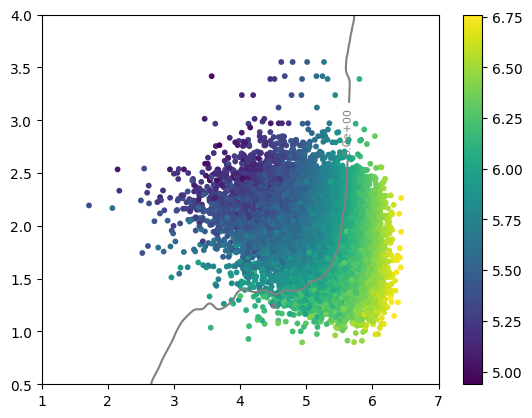

In [154]:
logx = np.log10(x)
logy = np.log10(y)
logc = np.log10(c)

plt.scatter(logx, logy, c=logc, s=10)
plt.colorbar()

plt.xlim(1, 7)
plt.ylim(0.5, 4)

#########################

# Create grid
xi = np.linspace(1, 7, 200)
yi = np.linspace(0.5, 4, 200)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((logx, logy), logc, (Xi, Yi), method="linear")

Zi_nearest = griddata((logx, logy), logc, (Xi, Yi), method="nearest")
Zi = np.where(np.isnan(Zi), Zi_nearest, Zi)

Zi_smooth = gaussian_filter(Zi, sigma=2)  # Increase sigma for smoother lines


mass_levels = [6]
cs = plt.contour(Xi, Yi, Zi_smooth, levels=mass_levels, colors="grey", linewidths=1.5)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1e")

# label_positions = [(3, 2), (4, 1.5), (5, 3)]  # example positions
# plt.clabel(cs, inline=True, fontsize=8, fmt="%.1e", manual=label_positions)

# plt.show()

In [155]:
def lower_envelope(x, m, x_b, y_b):
    return np.where(x < x_b, m * (x - x_b) + y_b, y_b)


def kde_threshold(Z, fraction):
    """Return KDE level that encloses fraction of total probability."""
    sorted_Z = np.sort(Z.ravel())[::-1]  # descending
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # normalize
    # Find the smallest Z value where cumulative sum >= fraction
    level = sorted_Z[np.searchsorted(cumsum, fraction)]
    return level


def plot_bounding(xlog, ylog, fraction=0.98):
    xy = np.vstack([xlog, ylog])
    kde = gaussian_kde(xy)
    xmin, xmax = xlog.min(), xlog.max()
    ymin, ymax = ylog.min(), ylog.max()

    X, Y = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    level = kde_threshold(Z, fraction)
    cont = plt.contour(X, Y, Z, levels=[level], colors="orange")
    plt.close()

    contour_path = cont.collections[0].get_paths()[0]
    vertices = contour_path.vertices
    x_contour, y_contour = vertices[:, 0], vertices[:, 1]

    # --- Keep only the "lower" part of the contour ---
    # We'll bin x values and take the minimum y in each bin
    bins = np.linspace(x_contour.min(), x_contour.max(), 100)
    x_bin_centers = 0.5 * (bins[:-1] + bins[1:])
    y_lower = []
    x_lower = []

    for i in range(len(bins) - 1):
        mask = (x_contour >= bins[i]) & (x_contour < bins[i + 1])
        if np.any(mask):
            x_lower.append(x_bin_centers[i])
            y_lower.append(np.min(y_contour[mask]))

    x_lower = np.array(x_lower)
    y_lower = np.array(y_lower)

    # --- Fit lower-envelope function ---
    p0 = [-1, np.median(x_lower), np.median(y_lower)]  # initial guess: slope, x_b, y_b
    params, cov = curve_fit(lower_envelope, x_lower, y_lower, p0=p0)

    xfit = np.logspace(1, 7)
    xfitlog = np.log10(xfit)
    yfitlog = lower_envelope(xfitlog, *params)
    yfit = 10**yfitlog

    plot_dict = {"xfit": xfit, "yfit": yfit, "params": params, "cov": cov}

    return plot_dict

In [157]:
logx = np.log10(x)
logy = np.log10(y)
logc = np.log10(c)

plot_dict = plot_bounding(logx, logy, fraction=0.98)

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_10412/2498956217.py:28: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = cont.collections[0].get_paths()[0]


<a list of 3 text.Text objects>

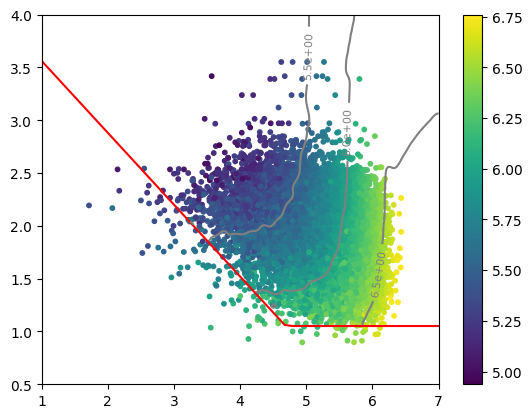

In [169]:
plt.scatter(logx, logy, c=logc, s=10)
plt.colorbar()

plt.xlim(1, 7)
plt.ylim(0.5, 4)

xfit = plot_dict["xfit"]
yfit = plot_dict["yfit"]

xfit_log = np.log10(xfit)
yfit_log = np.log10(yfit)

plt.plot(xfit_log, yfit_log, c="r")

#########################

# Create grid
xi = np.linspace(1, 7, 200)
yi = np.linspace(0.5, 4, 200)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((logx, logy), logc, (Xi, Yi), method="linear")

Zi_nearest = griddata((logx, logy), logc, (Xi, Yi), method="nearest")
Zi = np.where(np.isnan(Zi), Zi_nearest, Zi)

Zi_smooth = gaussian_filter(Zi, sigma=2)  # Increase sigma for smoother lines

y_boundary = np.interp(Xi[0, :], xfit_log, yfit_log)  # 1D array along x-axis
Y_boundary = np.tile(y_boundary, (Yi.shape[0], 1))
Zi_masked = np.where(Yi < Y_boundary, np.nan, Zi_smooth)

mass_levels = [5.5, 6, 6.5]
cs = plt.contour(Xi, Yi, Zi_masked, levels=mass_levels, colors="grey", linewidths=1.5)
plt.clabel(cs, inline=True, fontsize=8, fmt="%.1e")

# label_positions = [(3, 2), (4, 1.5), (5, 3)]  # example positions
# plt.clabel(cs, inline=True, fontsize=8, fmt="%.1e", manual=label_positions)

# plt.show()

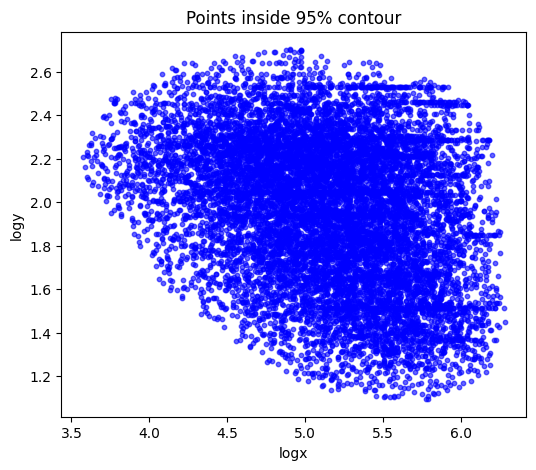

In [172]:
# Compute 2D density
xy = np.vstack([logx, logy])
kde = gaussian_kde(xy)
z = kde(xy)

# Determine threshold for 95% contour
threshold = np.percentile(z, 5)  # 5th percentile corresponds to outside 95%

# Mask values outside 95% contour
logx_masked = logx.copy()
logy_masked = logy.copy()
logx_masked[z < threshold] = np.nan
logy_masked[z < threshold] = np.nan

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(logx_masked, logy_masked, c="blue", s=10, alpha=0.6)
plt.xlabel("logx")
plt.ylabel("logy")
plt.title("Points inside 95% contour")
plt.show()
